In [ ]:
from kan import *
torch.set_default_dtype(torch.float64)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# create a KAN: 2D inputs, 1D output, and 5 hidden neurons. cubic spline (k=3), 5 grid intervals (grid=5).
kan_model = KAN(width=[2,5,1], grid=3, k=3, seed=42, device=device)
mpkan_model = MPKAN(width=[2,5,1], grid=3, k=3, seed=42, device=device)

cuda
checkpoint directory created: ./model
saving model version 0.0


Create dataset

In [ ]:
from kan.utils import create_dataset
from torch.distributions.normal import Normal

eps = 1e-6

# create dataset f(x,y) = exp(sin(pi*x)+y^2)
f = lambda x: (
    x[:, [0]].clamp(min=eps) * Normal(0, 1).cdf(
        (torch.log((x[:, [0]] / x[:, [1]].clamp(min=eps)).clamp(min=eps)) +
         (x[:, [3]] + 0.5 * x[:, [4]]**2) * x[:, [2]]) /
        (x[:, [4]].clamp(min=eps) * torch.sqrt(x[:, [2]].clamp(min=eps)) + eps)
    ) -
    x[:, [1]].clamp(min=eps) * torch.exp(-x[:, [3]] * x[:, [2]]) *
    Normal(0, 1).cdf(
        (torch.log((x[:, [0]] / x[:, [1]].clamp(min=eps)).clamp(min=eps)) +
         (x[:, [3]] - 0.5 * x[:, [4]]**2) * x[:, [2]]) /
        (x[:, [4]].clamp(min=eps) * torch.sqrt(x[:, [2]].clamp(min=eps)) + eps)
    )
)
dataset = create_dataset(f, n_var=2, train_num=100000, test_num=100000, device=device)
dataset['train_input'].shape, dataset['train_label'].shape

(torch.Size([10000, 5]), torch.Size([10000, 1]))

Plot KAN at initialization

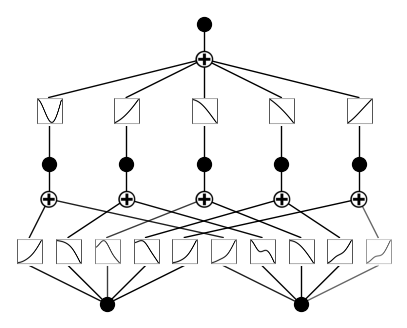

In [ ]:
# plot KAN at initialization
kan_model(dataset['train_input']);
kan_model.plot()

# plot MPKAN at initialization
mpkan_model(dataset['train_input']);
mpkan_model.plot()

Train KAN with sparsity regularization

In [4]:
# train the kan_model
kan_model.fit(dataset, opt="Adam", steps=50, lamb=0.001, profile=True)

| train_loss: 3.48e-01 | test_loss: 1.31e+00 | reg: 9.07e+00 | :   2%| | 1/50 [00:00<00:35,  1.38it/STAGE:2025-04-18 19:41:48 111532:111532 ActivityProfilerController.cpp:314] Completed Stage: Warm Up
| train_loss: 1.91e+00 | test_loss: 1.16e+00 | reg: 2.26e+01 | :   6%| | 3/50 [00:00<00:11,  4.24it/STAGE:2025-04-18 19:41:49 111532:111532 ActivityProfilerController.cpp:320] Completed Stage: Collection
STAGE:2025-04-18 19:41:49 111532:111532 ActivityProfilerController.cpp:324] Completed Stage: Post Processing
| train_loss: 1.52e-01 | test_loss: 1.50e-01 | reg: 5.81e+01 | : 100%|█| 50/50 [00:03<00:00, 13.78it


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                              aten::bmm         0.29%     720.000us         0.51%       1.254ms      59.714us      89.186ms        64.60%      89.237ms       4.249ms           0 b           0 b      14.67 Mb      10.08 M

{'train_loss': [array(0.34769867),
  array(1.31606336),
  array(2.6908504),
  array(1.9096796),
  array(1.17099705),
  array(0.90746361),
  array(0.5403387),
  array(0.99965659),
  array(0.77399096),
  array(0.49821419),
  array(1.5906985),
  array(3.53451436),
  array(2.17372834),
  array(1.67293214),
  array(0.84238748),
  array(1.13623952),
  array(0.82797104),
  array(0.54980988),
  array(0.35468326),
  array(0.43012505),
  array(0.52188274),
  array(0.88115831),
  array(0.95490686),
  array(0.57377779),
  array(0.32831924),
  array(0.5342772),
  array(0.6134407),
  array(0.46845589),
  array(0.35619934),
  array(0.35208328),
  array(0.35411364),
  array(0.36878954),
  array(0.43511123),
  array(0.3307317),
  array(0.33488886),
  array(0.2703179),
  array(0.26240778),
  array(0.30753552),
  array(0.28461711),
  array(0.29192315),
  array(0.2246107),
  array(0.22474971),
  array(0.21038135),
  array(0.20163957),
  array(0.20333475),
  array(0.14552079),
  array(0.1465683),
  array(0